In [1]:
# EDA - Home Office Immigration Statistics
# checking visa grant volumes by occupation - key for my background review chapter

import pandas as pd
import matplotlib.pyplot as plt

# this file has multiple tabs so checking what sheets are available first
xl = pd.ExcelFile('HO_ImmigStats_13Jun2026.xlsx')
print("sheets available:")
print(xl.sheet_names)

sheets available:
['Cover Sheet', 'Contents', 'Notes', 'List of Fields', 'Occ_D01', 'Data_Occ_D01', 'Occ_D02', 'Data_Occ_D02']


In [2]:
# loading the occupation data sheet
df = pd.read_excel('HO_ImmigStats_13Jun2026.xlsx', sheet_name='Data_Occ_D01')

# basic checks
print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
print("\nfirst 5 rows:")
print(df.head())

shape: (61980, 12)

columns: ['Applications for entry clearance visas, by occupation and industry, 2021 to 2026 Q1 - Dataset [Notes 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

first 5 rows:
  Applications for entry clearance visas, by occupation and industry, 2021 to 2026 Q1 - Dataset [Notes 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  \
0                                      Link to notes                                                                                            
1                                   Link to contents                                                                                            
2                                               Year                                                                                            
3                                               2021                        

In [3]:
# fixing headers - row 2 has the real column names
df.columns = df.iloc[2]
df = df.drop([0, 1, 2]).reset_index(drop=True)

# renaming the applications column so its easier to use
df.columns = ['Year', 'Quarter', 'Nationality', 'Region', 'Visa_Type', 
              'Visa_Subgroup', 'Industry', 'Occ_Major', 'Occ_SubMajor', 
              'Occ_Minor', 'Occ_Unit', 'Applications']

print("shape:", df.shape)
print("\nfirst 5 rows:")
print(df.head())
print("\nunique years:")
print(df['Year'].unique())
print("\nunique visa types:")
print(df['Visa_Type'].unique())

shape: (61977, 12)

first 5 rows:
   Year  Quarter Nationality Region Visa_Type           Visa_Subgroup  \
0  2021  2021 Q1           *      *    Worker  Health and Care Worker   
1  2021  2021 Q1           *      *    Worker  Health and Care Worker   
2  2021  2021 Q1           *      *    Worker  Health and Care Worker   
3  2021  2021 Q1           *      *    Worker  Health and Care Worker   
4  2021  2021 Q1           *      *    Worker  Health and Care Worker   

                                        Industry  \
0      Accommodation and Food Service Activities   
1  Administrative and Support Service Activities   
2                                      Education   
3                                      Education   
4                                      Education   

                                Occ_Major  \
0            2 - Professional Occupations   
1            2 - Professional Occupations   
2  3 - Associate Professional Occupations   
3            2 - Professional Occu

In [4]:
# filtering to just skilled worker visas and converting applications to numeric
df_worker = df[df['Visa_Type'] == 'Worker'].copy()
df_worker['Applications'] = pd.to_numeric(df_worker['Applications'], errors='coerce')

# grouping by year and industry to see totals
yearly = df_worker.groupby(['Year', 'Industry'])['Applications'].sum().reset_index()

print("industries available:")
print(df_worker['Industry'].unique())

industries available:
['Accommodation and Food Service Activities'
 'Administrative and Support Service Activities' 'Education'
 'Human Health and Social Work Activities'
 'Information and Communications'
 'Professional, Scientific and Technical Activities'
 'Public Admin and defence; compulsory social security'
 'Water supply; sewerage, waste management and remediation activities'
 'Wholesale and retail trade; repair of motor vehicles and motorcycles'
 'Activities of extraterritorial organisations and bodies'
 'Arts, Entertainment and Recreation' 'Construction'
 'Electricity, gas, steam and air conditioning supply'
 'Financial and Insurance Activities' 'Manufacturing'
 'Mining and Quarrying' 'Other Service Activities'
 'Real Estate Activities' 'Transportation and Storage'
 'Activities of households as employers; production activities of household for own use'
 'Agriculture, Forestry and Fishing'
 'Administrative and Support Activities']


In [5]:
# my 5 dissertation sectors mapped to industries in this dataset
my_sectors = ['Education', 'Human Health and Social Work Activities', 
              'Information and Communication', 
              'Financial and Insurance Activities',
              'Professional, Scientific and Technical Activities']

df_sectors = yearly[yearly['Industry'].isin(my_sectors)]

print("year on year applications for my sectors:")
print(df_sectors.pivot(index='Year', columns='Industry', values='Applications'))

year on year applications for my sectors:
Industry  Education  Financial and Insurance Activities  \
Year                                                      
2021           4394                                7284   
2022           5427                               12682   
2023           6376                                9532   
2024           4847                                8470   
2025           2557                                8142   
2026            390                                1812   

Industry  Human Health and Social Work Activities  \
Year                                                
2021                                        32358   
2022                                        79869   
2023                                       150735   
2024                                        28232   
2025                                        14064   
2026                                         1499   

Industry  Professional, Scientific and Technical Activities 

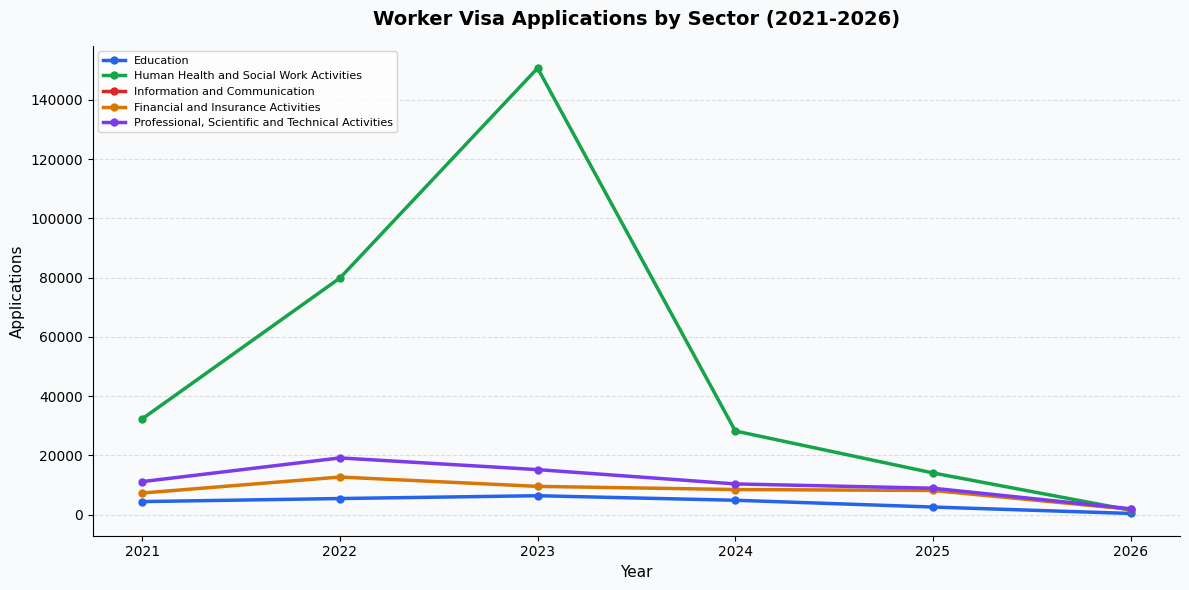

done!


In [6]:
# plotting year on year trend
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

colors = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']

for industry, color in zip(my_sectors, colors):
    data = yearly[yearly['Industry'] == industry]
    ax.plot(data['Year'], data['Applications'], 
            label=industry, color=color, linewidth=2.5, marker='o', markersize=5)

ax.set_title('Worker Visa Applications by Sector (2021-2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Applications', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('immig_stats_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("done!")

In [7]:
# notes for sprint 2
print("key findings from ImmigStats EDA:")
print("- years covered: 2021 to 2026 Q1")
print("- Worker and Temporary Worker visa types present")
print("- need to check which industries match my 5 sectors exactly in Sprint 2")

key findings from ImmigStats EDA:
- years covered: 2021 to 2026 Q1
- Worker and Temporary Worker visa types present
- need to check which industries match my 5 sectors exactly in Sprint 2


In [8]:
# extra findings
print("extra notes:")
print("- Healthcare peaked at 150,735 in 2023 then dropped sharply - major finding!")
print("- likely due to UK government restricting Health and Care Worker visa in 2024")
print("- 2026 data is partial (Q1 only) so low numbers are expected")
print("- Information and Communication column name has typo - fix in Sprint 2")
print("- this trend data is perfect for the scrollytelling narrative chapter")

extra notes:
- Healthcare peaked at 150,735 in 2023 then dropped sharply - major finding!
- likely due to UK government restricting Health and Care Worker visa in 2024
- 2026 data is partial (Q1 only) so low numbers are expected
- Information and Communication column name has typo - fix in Sprint 2
- this trend data is perfect for the scrollytelling narrative chapter
